In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.colors as colors
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple
from matplotlib import rc
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.cm
import copy
import os
import Prepare
from Prepare import Neutral, SOLPS


正在读取网格与数据文件...
成功读取！网格节点总数 N = 4167
R 坐标读取了 4167 个，前三个是: [1.7559 1.7559 1.7559]
Z 坐标读取了 4167 个，前三个是: [-1.1  -1.04 -1.  ]


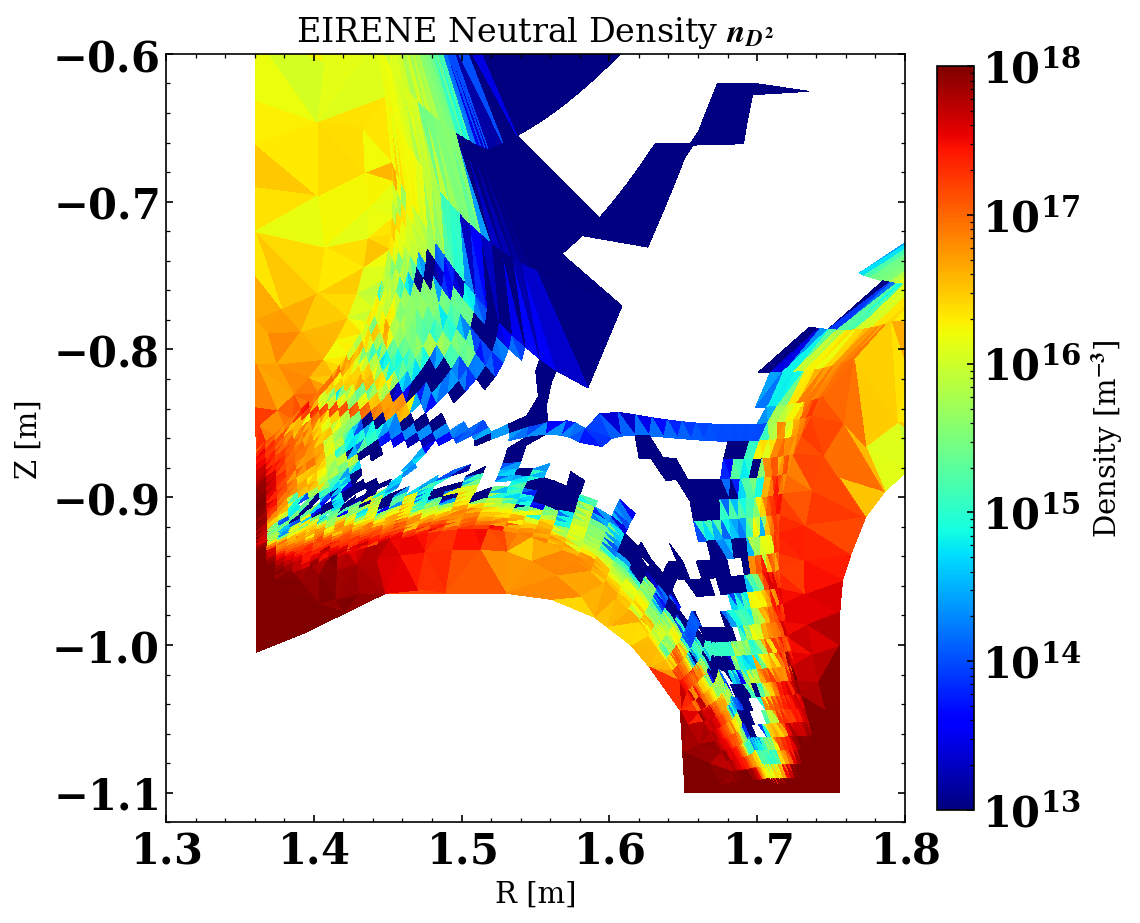

In [3]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import matplotlib.colors as colors
import numpy as np
case = 4
n_D2_Tri = np.loadtxt("/data/leuven/379/vsc37950/nt/Outputfile/test/data/n_D2_0_Tri")
n_D_Tri = Prepare.EAST_tri[case].n_D_0_Tri

# ==========================================
# 1. 读取 EIRENE 原始数据文件
# ==========================================
print("正在读取网格与数据文件...")

# 1. 读取节点坐标 (fort.33)
# 假设前两列分别是 R (X) 和 Z (Y) 坐标
# 如果文件有表头，可以加上 skiprows=1
with open("/data/leuven/379/vsc37950/nt/case_input/2MW-3.2e19/solps_output/fort.33", "r") as f:
    raw_text = f.read()

# 2. 魔法操作：用 split() 把所有数字拆成一个一维的长列表
# split() 会自动把所有空格、换行符全部吃掉，无视“每排4个”的限制
all_numbers = raw_text.split()

# 3. 按照你描述的顺序，逐个提取（提取的同时转成浮点数/整数）

# 第 1 个数字是点的数量 (转成整数)
n_nodes = int(all_numbers[0])
print(f"成功读取！网格节点总数 N = {n_nodes}")

# 紧接着的 n_nodes 个数字是 R 坐标 (转成 numpy 数组方便后续画图)
R_nodes = np.array([float(x) for x in all_numbers[1 : 1 + n_nodes]])/100

# 再紧接着的 n_nodes 个数字是 Z 坐标
Z_nodes = np.array([float(x) for x in all_numbers[1 + n_nodes : 1 + 2 * n_nodes]])/100

# 简单验证一下读取是否正确
print(f"R 坐标读取了 {len(R_nodes)} 个，前三个是: {R_nodes[:3]}")
print(f"Z 坐标读取了 {len(Z_nodes)} 个，前三个是: {Z_nodes[:3]}")

# 2. 读取三角形连接矩阵 (fort.34)
# 假设文件里每行代表一个三角形，前三列是组成它的三个节点编号
# 注意：必须指定 dtype=int，否则会以浮点数读取，无法作为索引
elements = np.loadtxt("/data/leuven/379/vsc37950/nt/case_input/2MW-3.2e19/solps_output/fort.34", dtype=int, skiprows=1)

# 【核心天坑】：EIRENE(Fortran)索引从1开始，Python从0开始，必须全体减1！
triangles = elements[:, 1:4] - 1  

# ==========================================
# 2. 构建 matplotlib 的三角网格对象
# ==========================================
triangulation = mtri.Triangulation(R_nodes, Z_nodes, triangles)

# （可选）过滤掉密度为 0 或极小的无效网格，防止取对数时报错
mask = (n_D_Tri <= 1e-10)
triangulation.set_mask(mask)

# ==========================================
# 3. 开始绘制高质量伪彩图
# ==========================================
# 设置全局字体为学术衬线字体
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Times New Roman']

fig, ax = plt.subplots(figsize=(8, 10), dpi=150)

# 使用 tripcolor 绘制三角形中心数据
# norm=colors.LogNorm() 开启对数坐标，非常适合画跨度极大的密度分布
tc = ax.tripcolor(triangulation, 
                  facecolors=n_D2_Tri, 
                  cmap='jet', 
                  norm=colors.LogNorm(vmin=1e13, vmax=1e18), # 请根据你的实际密度上下限修改
                  edgecolors='none',  # 如果网格太密，建议设为 'none' 不画黑线；如果网格稀疏，可以设为 'k'
                  linewidth=0.1)

# 设置坐标轴与比例
ax.set_aspect('equal', adjustable='box') # 保持物理比例 1:1
ax.set_xlim(1.30, 1.80) # 如果需要局部放大，取消这行的注释
ax.set_ylim(-1.12, -0.60)

# 添加标签与标题
ax.set_xlabel("R [m]", fontsize=14)
ax.set_ylabel("Z [m]", fontsize=14)
ax.set_title("EIRENE Neutral Density ${n}_{{D}^{2}}$", fontsize=16)

# 添加 Colorbar
cbar = fig.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Density [m$^{-3}$]", fontsize=14)

# 保存与显示
fig.savefig("EIRENE_nD_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

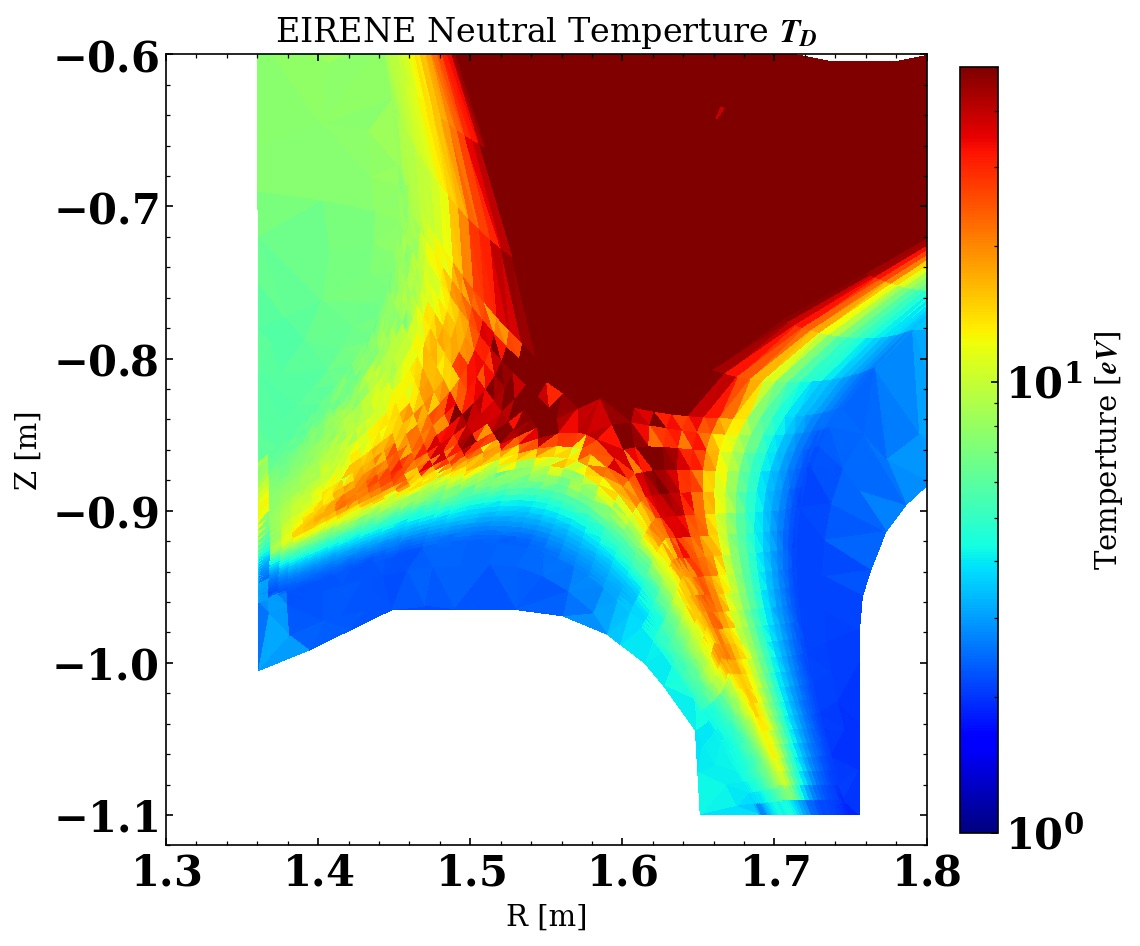

In [4]:
fig, ax = plt.subplots(figsize=(8, 10), dpi=150)

# 使用 tripcolor 绘制三角形中心数据
# norm=colors.LogNorm() 开启对数坐标，非常适合画跨度极大的密度分布
tc = ax.tripcolor(triangulation, 
                  facecolors=Prepare.EAST_tri[4].T_D_0_Tri, 
                  cmap='jet', 
                  norm=colors.LogNorm(vmin=1, vmax=50), # 请根据你的实际密度上下限修改
                  edgecolors='none',  # 如果网格太密，建议设为 'none' 不画黑线；如果网格稀疏，可以设为 'k'
                  linewidth=0.1)

# 设置坐标轴与比例
ax.set_aspect('equal', adjustable='box') # 保持物理比例 1:1
ax.set_xlim(1.30, 1.80) # 如果需要局部放大，取消这行的注释
ax.set_ylim(-1.12, -0.60)

# 添加标签与标题
ax.set_xlabel("R [m]", fontsize=14)
ax.set_ylabel("Z [m]", fontsize=14)
ax.set_title("EIRENE Neutral Temperture ${T}_{D}$", fontsize=16)

# 添加 Colorbar
cbar = fig.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Temperture [$eV$]", fontsize=14)

# 保存与显示
fig.savefig("EIRENE_nD_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()

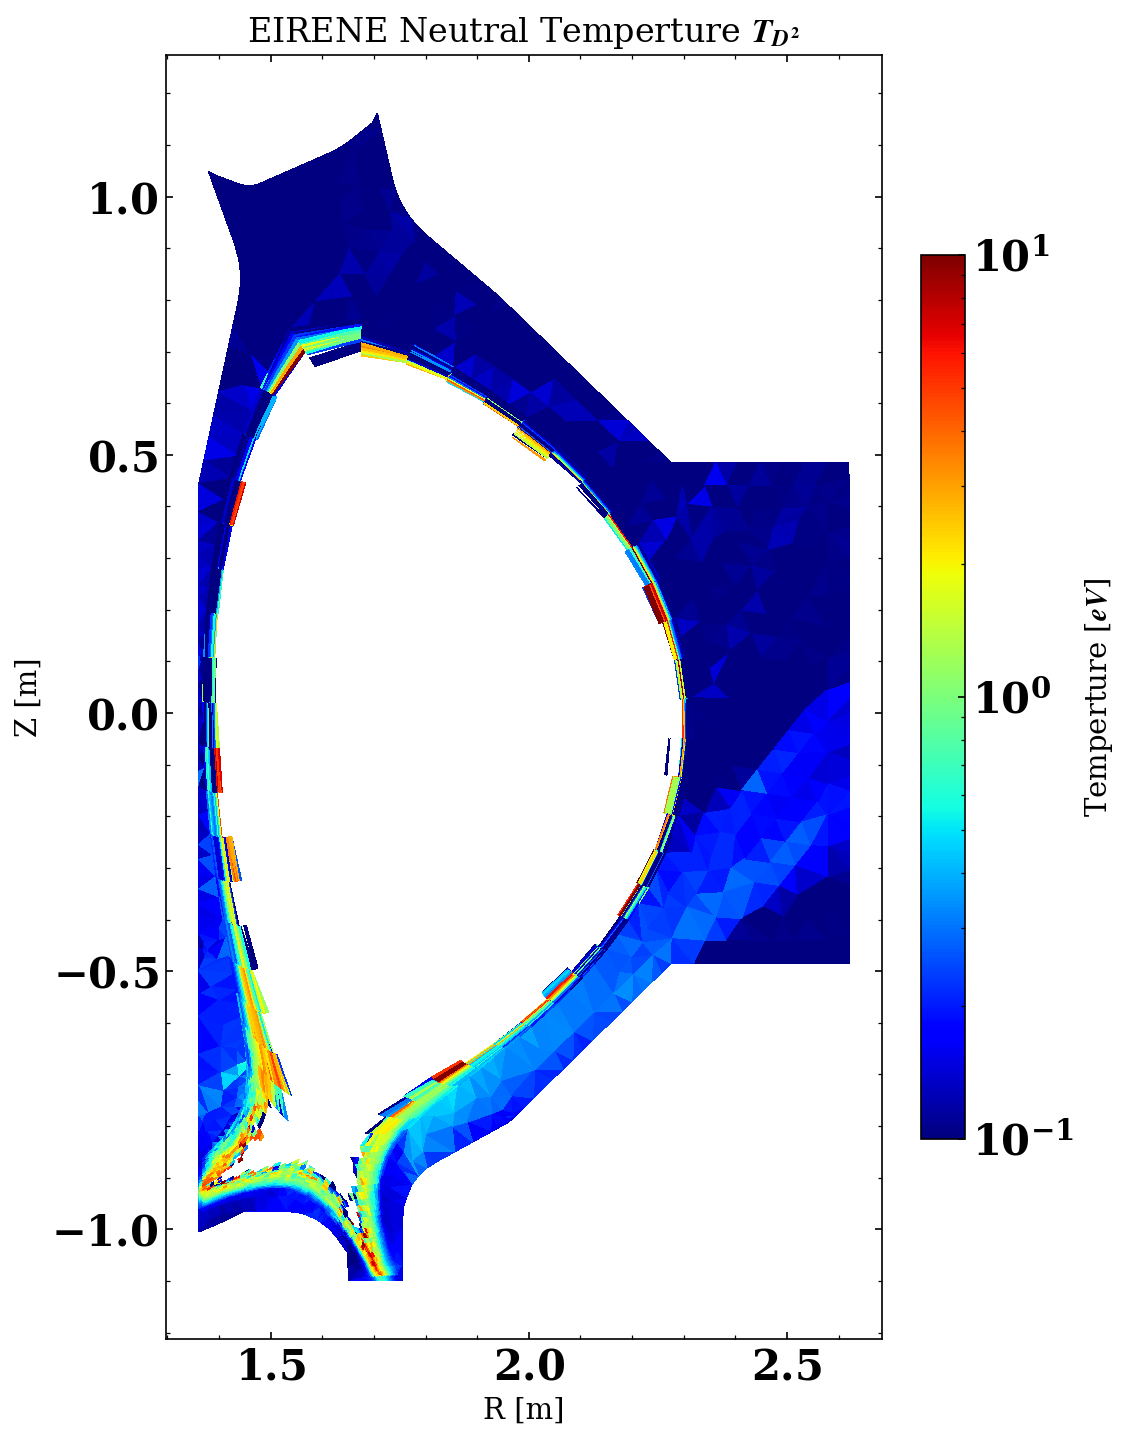

In [10]:
fig, ax = plt.subplots(figsize=(8, 10), dpi=150)

# 使用 tripcolor 绘制三角形中心数据
# norm=colors.LogNorm() 开启对数坐标，非常适合画跨度极大的密度分布
tc = ax.tripcolor(triangulation, 
                  facecolors=Prepare.EAST_tri[4].T_D2_0_Tri, 
                  cmap='jet', 
                  norm=colors.LogNorm(vmin=0.1, vmax=10), # 请根据你的实际密度上下限修改
                  edgecolors='none',  # 如果网格太密，建议设为 'none' 不画黑线；如果网格稀疏，可以设为 'k'
                  linewidth=0.1)

# 设置坐标轴与比例
ax.set_aspect('equal', adjustable='box') # 保持物理比例 1:1
#ax.set_xlim(1.30, 1.80) # 如果需要局部放大，取消这行的注释
#ax.set_ylim(-1.12, -0.60)

# 添加标签与标题
ax.set_xlabel("R [m]", fontsize=14)
ax.set_ylabel("Z [m]", fontsize=14)
ax.set_title("EIRENE Neutral Temperture ${T}_{D^2}$", fontsize=16)

# 添加 Colorbar
cbar = fig.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Temperture [$eV$]", fontsize=14)

# 保存与显示
fig.savefig("EIRENE_nD_Distribution.png", dpi=300, bbox_inches='tight')
plt.show()